# Comparing the candidate methods

**A limitation on the weighting of the recovery values.** Sections 3 and 6 weight each stratum by its count in the stochastic candidate pool from which the labelled pairs were drawn, rather than by the size of the complete disagreement region. Exact enumeration over the same eligible crops gives a different region composition, under which the ordering of the leading descriptive recovery estimates reverses. Because the labelled draw also caps pairs per cluster, a corrected weighting requires an explicitly defined estimand and cluster-aware uncertainty rather than a substitution of region sizes. The recovery percentages below are therefore descriptive summaries of the labelled sample and do not establish a population ordering of reach; the labelled counts themselves do not depend on the weighting. The chapter README, §6.4, states the same limitation alongside the affected figure.

**The decision.** Notebook 3 selected HDBSCAN under its encoded rule, then measured that the
rule could not work: eleven negative pairs, no configuration excluded by either eligibility gate,
twenty of twenty-four tied at precision 1.000. It also recorded that one family, connected
components on a thresholded graph, was excluded in the recorded protocol by an assumption nobody had
measured. This notebook settles both.

**The evidence.** 250 crop pairs drawn from the regions where the three methods disagree, judged
blind, plus a 60-pair blind re-review of the same material. Thirty-five of the 250 are genuine
mismatches, against sixteen in the whole of notebook 3's annotation.

**What it produces.** A precision and a fragmentation estimate for each method on identical
evidence, and a stated ground for keeping or replacing the frozen choice. It does not re-select from
a grid, and it does not use the hand-curated fleuron classes anywhere in its primary result.

**How to read it.** Section 2 tests the assumption that excluded connected components, and shows
that on notebook 3's own evidence that method wins. Sections 3 and 4 describe the new benchmark
before it decides anything. Sections 5 and 6 are the two halves of the answer, precision and
fragmentation, and Section 7 concludes. No part of the comparison uses the hand-curated fleuron
classes.

## 1. Configuration and inputs

Every input is a frozen artifact. The three clusterings are read as label vectors rather than
recomputed, except connected components, which is rebuilt here from the cached neighbour graph so
that this notebook is self-contained; the rebuild is asserted against the frozen labels.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.stats import binomtest, fisher_exact

NOTEBOOK_DIR = Path.cwd().resolve()
assert NOTEBOOK_DIR.name == '2_clustering', \
    'Run this notebook from its own folder, 2_clustering/.'
PROJECT_DIR = NOTEBOOK_DIR.parent

RUN_TAG = '_rerun1'
ALLOW_OVERWRITE = False


def guarded_mkdir(path):
    """Create an output directory, refusing to overwrite a populated one."""
    if path.exists() and any(path.iterdir()) and not (RUN_TAG or ALLOW_OVERWRITE):
        raise RuntimeError(
            f'{path} already contains results. Set RUN_TAG to write elsewhere, '
            f'or ALLOW_OVERWRITE = True to replace them.')
    path.mkdir(parents=True, exist_ok=True)


FEATURE_RUN_ID = 'all_regions_v1_minside24_dinov2_vitb14_binarized_v1'
BENCHMARK_DIR = PROJECT_DIR / '2_clustering_outputs' / f'{FEATURE_RUN_ID}_clustering_benchmark_v1'
METHOD_DIR = BENCHMARK_DIR / 'method_comparison'
DISAGREEMENT_DIR = BENCHMARK_DIR / 'disagreement_v1'
OUTPUT_DIR = BENCHMARK_DIR / f'method_evaluation_v1{RUN_TAG}'
FIGURES_DIR = OUTPUT_DIR / 'figures'
guarded_mkdir(OUTPUT_DIR)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# The encoded rule of notebook 3, restated so this notebook can apply it unchanged.
PRECISION_TARGET = 0.90
MAX_LARGEST_CLUSTER_FRACTION = 0.10
CC_THRESHOLD = 0.95

manifest = pd.read_csv(METHOD_DIR / 'selected_clusters.csv')
knn_indices = np.load(METHOD_DIR / 'knn_k20_indices.npy')
knn_similarities = np.load(METHOD_DIR / 'knn_k20_similarities.npy')

hdbscan_labels = np.load(METHOD_DIR / 'selected_cluster_labels.npy')
with np.load(METHOD_DIR / 'graph_grid_labels.npz') as archive:
    graph_labels = archive['graph_core0.97_expand0.90']


def connected_component_labels(threshold, minimum_size=2):
    """Connected components of the graph keeping neighbour edges at or above `threshold`."""
    n_crops, k = knn_indices.shape
    rows = np.repeat(np.arange(n_crops), k)
    keep = knn_similarities.reshape(-1) >= threshold
    graph = coo_matrix((np.ones(int(keep.sum())),
                        (rows[keep], knn_indices.reshape(-1)[keep])), shape=(n_crops, n_crops))
    _, labels = connected_components(graph, directed=False)
    sizes = pd.Series(labels).value_counts()
    return np.where(pd.Series(labels).map(sizes).to_numpy() >= minimum_size, labels, -1)


cc_labels = connected_component_labels(CC_THRESHOLD)
np.testing.assert_array_equal(cc_labels >= 0,
                              np.load(BENCHMARK_DIR / 'robustness_v1' / 'cc095_labels.npy') >= 0)

METHODS = {'HDBSCAN': hdbscan_labels, 'mutual-kNN': graph_labels,
           f'CC @ {CC_THRESHOLD:g}': cc_labels}
for name, labels in METHODS.items():
    assert len(labels) == len(manifest)
    print(f'{name:12s} clusters {pd.Series(labels[labels >= 0]).nunique():5d}   '
          f'crops assigned {int((labels >= 0).sum()):6,d}')

HDBSCAN      clusters   140   crops assigned  7,160
mutual-kNN   clusters   781   crops assigned 10,972
CC @ 0.95    clusters  1141   crops assigned  9,139


## 2. The family notebook 3 never tested

The protocol excluded connected components on the assumption that a thresholded similarity graph
would chain: A resembles B, B resembles C, and transitivity drags unrelated designs into one
component. The mutual-kNN method of notebook 3 was designed to prevent exactly that. The assumption
was stated but never measured, so it is measured here, and the method is then scored under the rule
exactly as written.

In [2]:
identity_pairs = pd.read_csv(BENCHMARK_DIR / 'pair_review' / 'pair_candidates.csv').merge(
    pd.read_csv(BENCHMARK_DIR / 'pair_review' / 'pair_review_labels.csv')[['pair_id', 'label']],
    on='pair_id')
identity_pairs = identity_pairs[identity_pairs.label.isin(['same_fleuron', 'different'])]
calibration = identity_pairs[identity_pairs.benchmark_split == 'calibration']


def score_on_calibration(labels):
    """Pair precision, recall and F0.5 on the calibration split, as notebook 3 defined them."""
    left, right = labels[calibration.left_index.to_numpy()], labels[calibration.right_index.to_numpy()]
    predicted_same = (left >= 0) & (left == right)
    truly_same = calibration.label.eq('same_fleuron').to_numpy()
    true_positive = int((predicted_same & truly_same).sum())
    false_positive = int((predicted_same & ~truly_same).sum())
    false_negative = int((~predicted_same & truly_same).sum())
    precision = true_positive / max(true_positive + false_positive, 1)
    recall = true_positive / max(true_positive + false_negative, 1)
    f_half = (1.25 * precision * recall / (0.25 * precision + recall)) if precision + recall else 0.0
    return precision, recall, f_half


rows = []
for threshold in [0.85, 0.87, 0.89, 0.91, 0.93, 0.95, 0.97]:
    labels = connected_component_labels(threshold)
    sizes = pd.Series(labels[labels >= 0]).value_counts()
    largest = int(sizes.max()) if len(sizes) else 0
    precision, recall, f_half = score_on_calibration(labels)
    rows.append({'threshold': threshold, 'clusters': int(len(sizes)),
                 'largest_cluster': largest, 'largest_share': largest / len(manifest),
                 'coverage': float((labels >= 0).mean()),
                 'precision': precision, 'recall': recall, 'f0_5': f_half,
                 'eligible': bool(precision >= PRECISION_TARGET
                                  and largest / len(manifest) <= MAX_LARGEST_CLUSTER_FRACTION)})
chaining = pd.DataFrame(rows)
chaining.to_csv(OUTPUT_DIR / 'connected_components_sweep.csv', index=False)

hdbscan_calibration = score_on_calibration(hdbscan_labels)
graph_calibration = score_on_calibration(graph_labels)
display(chaining.round(3))
print(f'HDBSCAN     on the same pairs: precision {hdbscan_calibration[0]:.3f}, '
      f'recall {hdbscan_calibration[1]:.3f}, F0.5 {hdbscan_calibration[2]:.3f}')
print(f'mutual-kNN  on the same pairs: precision {graph_calibration[0]:.3f}, '
      f'recall {graph_calibration[1]:.3f}, F0.5 {graph_calibration[2]:.3f}')

,threshold,clusters,largest_cluster,largest_share,coverage,precision,recall,f0_5,eligible
0,0.85,106,20733,0.953,0.974,0.901,0.989,0.917,False
1,0.87,197,19848,0.913,0.950,0.900,0.978,0.915,False
2,0.89,364,18032,0.829,0.904,0.899,0.967,0.912,False
3,0.91,639,14751,0.678,0.815,0.924,0.924,0.924,False
4,0.93,1042,7978,0.367,0.650,0.975,0.859,0.950,False
5,0.95,1141,1717,0.079,0.420,1.000,0.685,0.916,True
6,0.97,781,560,0.026,0.173,1.000,0.304,0.686,True


HDBSCAN     on the same pairs: precision 1.000, recall 0.587, F0.5 0.877
mutual-kNN  on the same pairs: precision 1.000, recall 0.489, F0.5 0.827


**Takeaway.** The assumption was correct where it was applied and wrong where it was not. At the
0.89 identity threshold of notebook 3, connected components places 83% of the corpus in a single
component, exactly the chaining the protocol predicted. That collapse is rejected by the
largest-cluster constraint alone, which is the clearest evidence in the chapter that the structural
constraint is load bearing rather than decorative.

Above 0.93 the chaining stops. At 0.95 the largest component holds 7.9% of the corpus, the method
becomes eligible, and under the rule exactly as written it **beats the selected method on every
tie-breaker**: F0.5 0.916 against 0.877, on higher recall and higher coverage.

Notebook 3 therefore selected a method that a candidate outside its grid would have displaced. That
is not yet a reason to change the selection, because Section 7 of notebook 3 established that this
same annotation cannot rank methods at all: twenty of twenty-four configurations tied at precision
1.000 on eleven negatives. A ranking produced by an instrument with no resolution is not evidence
either way. The rest of this notebook builds an instrument that has some.

## 3. Where the three methods disagree

Two methods that group the same pair tell you nothing about which is better. All the information
about their relative quality sits in the pairs they treat differently, so that is where the new
annotation was drawn. This section measures how large that region is, and how it is divided.

In [3]:
pool = pd.read_csv(DISAGREEMENT_DIR / 'disagreement_pool.csv')
region_sizes = pool.stratum.value_counts()

REGION_LABELS = {'only_hdbscan': 'only HDBSCAN', 'only_graph': 'only mutual-kNN',
                 'only_cc': f'only CC @ {CC_THRESHOLD:g}',
                 'hdbscan_graph_not_cc': 'HDBSCAN + kNN, not CC',
                 'hdbscan_cc_not_graph': 'HDBSCAN + CC, not kNN',
                 'graph_cc_not_hdbscan': 'kNN + CC, not HDBSCAN',
                 'all_three': 'all three (control)'}
regions = (region_sizes.rename('candidate_pairs').rename_axis('stratum').reset_index())
regions['region'] = regions.stratum.map(REGION_LABELS)
regions['share'] = regions.candidate_pairs / regions.candidate_pairs.sum()
regions.to_csv(OUTPUT_DIR / 'disagreement_regions.csv', index=False)
display(regions[['region', 'candidate_pairs', 'share']].round(3).set_index('region'))

,candidate_pairs,share
region,,
only HDBSCAN,27303,0.272
"HDBSCAN + CC, not kNN",26459,0.264
all three (control),20350,0.203
only mutual-kNN,13745,0.137
"kNN + CC, not HDBSCAN",4483,0.045
only CC @ 0.95,4235,0.042
"HDBSCAN + kNN, not CC",3708,0.037


**Takeaway.** The unilateral regions are the interesting ones, and they are strikingly unequal.
HDBSCAN merges roughly 27,000 pairs that neither other method will touch, against 4,200 for
connected components, a factor of six. That asymmetry is a property of the methods rather than of
the sampling: HDBSCAN takes far more decisions on its own authority, so it has far more
opportunities to be wrong, and far more opportunities to find something the others miss. Which of
those it is doing is precisely what the annotation resolves.

## 4. The benchmark, and how far it can be trusted

250 pairs were drawn at fixed quotas from the seven regions, rendered blind as two crops and an
identifier, and judged as `same_fleuron`, `different`, or `non_fleuron` where either crop is not a
usable ornament. Crops were restricted to ornament-like ones by image properties alone, aspect
ratio, minimum side, ink coverage and ink contact with the crop border, so the filter is blind to
every clustering and cannot favour one of them. No more than three pairs share a cluster.

Because the whole comparison rests on one reviewer in one session, 60 of the pairs were then
presented again, renumbered, reshuffled and with the two crops swapped, and judged a second time.

In [4]:
disagreement = pd.read_csv(DISAGREEMENT_DIR / 'disagreement_key.csv').merge(
    pd.read_csv(DISAGREEMENT_DIR / 'disagreement_labels.csv', keep_default_na=False)[
        ['pair_id', 'label']], on='pair_id')
assert disagreement.label.ne('').all(), 'the benchmark is not fully labelled'

composition = pd.crosstab(disagreement.stratum.map(REGION_LABELS), disagreement.label)
identity = disagreement[disagreement.label.isin(['same_fleuron', 'different'])].copy()
identity['is_same'] = identity.label.eq('same_fleuron')

rereview = pd.read_csv(DISAGREEMENT_DIR / 'rereview_v1' / 'rereview_key.csv').merge(
    pd.read_csv(DISAGREEMENT_DIR / 'rereview_v1' / 'rereview_labels.csv',
                keep_default_na=False)[['rereview_id', 'label']], on='rereview_id',
    suffixes=('_first', '_second'))
rereview['agrees'] = rereview.label_first == rereview.label_second
agreement = (rereview.groupby('label_first')
             .agree_frame if False else
             rereview.groupby('label_first').agrees.agg(['sum', 'size']))
agreement['agreement'] = agreement['sum'] / agreement['size']

display(composition)
print(f'identity pairs usable      : {len(identity)} of {len(disagreement)}, '
      f'of which {int((~identity.is_same).sum())} are genuine mismatches')
print(f'notebook 3 had, in total   : 16 mismatches\n')
print('blind re-review, agreement with the first judgement')
display(agreement.rename(columns={'sum': 'agreed', 'size': 'pairs'}))

label,different,non_fleuron_different,non_fleuron_same,same_fleuron
stratum,,,,
"HDBSCAN + CC, not kNN",0,0,2,28
"HDBSCAN + kNN, not CC",2,0,2,26
all three (control),0,0,0,25
"kNN + CC, not HDBSCAN",0,0,3,27
only CC @ 0.95,4,0,5,36
only HDBSCAN,16,2,3,24
only mutual-kNN,13,0,1,31


identity pairs usable      : 232 of 250, of which 35 are genuine mismatches
notebook 3 had, in total   : 16 mismatches

blind re-review, agreement with the first judgement


,agreed,pairs,agreement
label_first,,,
different,35,35,1.0
same_fleuron,25,25,1.0


**Takeaway.** The annotation contains **35 genuine mismatches**, against sixteen in the whole of
notebook 3, and they sit where the methods actually differ rather than in the low-similarity bands
where no clustering makes a decision.

The re-review agrees with the first judgement on **60 pairs out of 60**, on both labels. The
identity criterion is therefore reproducible for this reviewer, and the concern that the mismatch
rate rose across the session because of fatigue is not supported: the pairs judged late replicate
exactly. The chapter's other re-review, of 50 pairs drawn from the pair benchmark and the
within-cluster audit, agrees: identity was stable 36 times out of 36, while every one of its nine
disagreements involved the `non_fleuron` label. Two instruments on different material therefore
agree that identity is the stable judgement and usability is not.

Three limits stay on the record. This is agreement with oneself, not with a second reviewer;
recognition of a previously seen pair cannot be excluded despite the renumbering and the swap; and
these 60 pairs were drawn to carry this comparison, so they hold only `same_fleuron` and
`different` judgements and test the identity criterion alone.

## 5. Precision: what each method gets wrong when it acts alone

A pair merged by one method and refused by another is a direct test of both. This section reports,
for each unilateral region, how often the merge was wrong. Because the quotas were equal while the
regions are not, no rate here is pooled across regions; each is reported on its own.

In [5]:
def wilson_interval(successes, total):
    if total == 0:
        return np.nan, np.nan
    return binomtest(int(successes), int(total)).proportion_ci(0.95)


cluster_sizes = {name: pd.Series(labels[labels >= 0]).value_counts()
                 for name, labels in METHODS.items()}
UNILATERAL = {'only_hdbscan': ('HDBSCAN', 'cluster_hdbscan'),
              'only_graph': ('mutual-kNN', 'cluster_graph'),
              'only_cc': (f'CC @ {CC_THRESHOLD:g}', 'cluster_cc')}

rows = []
for stratum, (method, cluster_column) in UNILATERAL.items():
    group = identity[identity.stratum == stratum]
    wrong, total = int((~group.is_same).sum()), len(group)
    low, high = wilson_interval(wrong, total)
    # Sampling drew clusters uniformly, so re-weight by each cluster's pair count as a check.
    size = group[cluster_column].map(cluster_sizes[method])
    weights = size * (size - 1) / 2
    rows.append({'method': method, 'pairs_judged': total, 'wrong': wrong,
                 'error_rate': wrong / total, 'ci95_lower': low, 'ci95_upper': high,
                 'error_rate_pair_weighted': float(np.average(~group.is_same, weights=weights))})
unilateral = pd.DataFrame(rows)
unilateral.to_csv(OUTPUT_DIR / 'unilateral_error_rates.csv', index=False)
display(unilateral.round(3).set_index('method'))

hd = identity[identity.stratum == 'only_hdbscan']
cc = identity[identity.stratum == 'only_cc']
table = [[int((~hd.is_same).sum()), int(hd.is_same.sum())],
         [int((~cc.is_same).sum()), int(cc.is_same.sum())]]
print(f'HDBSCAN alone vs CC alone, Fisher exact p = {fisher_exact(table)[1]:.4g}\n')

correct = pd.DataFrame({name: identity[f'merged_{key}'].eq(identity.is_same)
                        for name, key in [('HDBSCAN', 'hdbscan'), ('mutual-kNN', 'graph'),
                                          (f'CC @ {CC_THRESHOLD:g}', 'cc')]})
paired_rows = []
names = list(correct.columns)
for i in range(len(names)):
    for j in range(i + 1, len(names)):
        a, b = names[i], names[j]
        only_a = int((correct[a] & ~correct[b]).sum())
        only_b = int((~correct[a] & correct[b]).sum())
        paired_rows.append({'comparison': f'{a} vs {b}', f'first_only': only_a,
                            'second_only': only_b,
                            'mcnemar_p': binomtest(only_a, only_a + only_b).pvalue})
paired = pd.DataFrame(paired_rows)
paired.to_csv(OUTPUT_DIR / 'paired_correctness_tests.csv', index=False)
print('per-pair correctness, paired across methods on identical pairs')
display(paired.round(4).set_index('comparison'))

,pairs_judged,wrong,error_rate,ci95_lower,ci95_upper,error_rate_pair_weighted
method,,,,,,
HDBSCAN,40,16,0.400,0.249,0.567,0.344
mutual-kNN,44,13,0.295,0.168,0.452,0.269
CC @ 0.95,40,4,0.100,0.028,0.237,0.127


HDBSCAN alone vs CC alone, Fisher exact p = 0.003799

per-pair correctness, paired across methods on identical pairs


,first_only,second_only,mcnemar_p
comparison,,,
HDBSCAN vs mutual-kNN,65,74,0.4976
HDBSCAN vs CC @ 0.95,54,81,0.0249
mutual-kNN vs CC @ 0.95,61,79,0.1505


In [6]:
size_rows = []
for stratum, (method, cluster_column) in UNILATERAL.items():
    group = identity[identity.stratum == stratum].copy()
    group['cluster_size'] = group[cluster_column].map(cluster_sizes[method])
    band = pd.cut(group.cluster_size, [0, 25, 100, 10 ** 6], labels=['<25', '25-100', '>100'])
    for label, part in group.groupby(band, observed=True):
        size_rows.append({'method': method, 'cluster_size': label, 'pairs': len(part),
                          'wrong': int((~part.is_same).sum()),
                          'error_rate': float((~part.is_same).mean())})
by_size = pd.DataFrame(size_rows)
by_size.to_csv(OUTPUT_DIR / 'error_rate_by_cluster_size.csv', index=False)
display(by_size.pivot(index='cluster_size', columns='method', values='error_rate').round(3))

method,CC @ 0.95,HDBSCAN,mutual-kNN
cluster_size,,,
25-100,0.000,0.333,0.323
<25,0.000,0.200,0.231
>100,0.182,0.571,NaN


**Takeaway.** When HDBSCAN merges a pair no other method will, it is wrong in **40%** of cases,
against **10%** for connected components and 30% for mutual-kNN. The difference between the two
extremes is not a small-sample artefact: Fisher exact *p* = 0.0038, and on per-pair correctness
across all 232 identity pairs HDBSCAN loses to connected components with McNemar *p* = 0.025.
HDBSCAN and mutual-kNN are indistinguishable, *p* = 0.50.

The pool was built by drawing clusters uniformly and then members, which weights every cluster
equally rather than every merged pair. Re-weighting by each cluster's pair count moves HDBSCAN to
34.4% and connected components to 12.7%. The gap narrows and the ordering is unchanged.

The second table locates the failure. HDBSCAN's errors **rise with cluster size**, from 20% below
25 members to 57% above 100. This cuts against the chapter's stability analysis, where small
clusters were the unstable ones, and it identifies a different failure mode: the large clusters are
absorbing unrelated designs. It also explains the mechanism behind the headline, since a method that
grows large clusters gains reach and loses precision by the same act.

## 6. Fragmentation: what each method fails to bring together

Precision on its own is not a criterion, because it can always be improved by merging less. A method
that placed every crop in its own cluster would never commit a false merge and would be useless.
The complementary quantity is measured from the same labels: of the pairs the reviewer judged to
show the same design, how many did each method actually place together. The structural evidence
that accompanies it, cluster counts and reach across works, is derived from filenames and needs no
reference partition.

In [7]:
import sys
sys.path.insert(0, str(PROJECT_DIR))
import book_identifiers

work_table, _ = book_identifiers.identifier_table(manifest.stem.unique())
work_of_scan = dict(zip(work_table.filename, work_table.work_id))
manifest['work_id'] = manifest.stem.map(work_of_scan)

same_pairs = identity[identity.is_same].copy()
# The quotas were equal across regions while the regions are not, so a plain average over the
# labelled pairs would describe the sampling design rather than the corpus. Each pair therefore
# carries its design weight: the size of its region in the pool over the number drawn from it.
drawn_per_region = disagreement.stratum.value_counts()
same_pairs['design_weight'] = (same_pairs.stratum.map(region_sizes)
                               / same_pairs.stratum.map(drawn_per_region))
rows = []
for name, key in [('HDBSCAN', 'hdbscan'), ('mutual-kNN', 'graph'),
                  (f'CC @ {CC_THRESHOLD:g}', 'cc')]:
    labels = METHODS[name]
    sizes = cluster_sizes[name]
    assigned = manifest[labels >= 0].assign(cluster_id=labels[labels >= 0])
    works_per_cluster = assigned.groupby('cluster_id').work_id.nunique()
    recovered = float(np.average(same_pairs[f'merged_{key}'],
                                 weights=same_pairs.design_weight))
    merged_pairs = sizes * (sizes - 1) / 2
    rows.append({'method': name,
                 'true_pairs_recovered': recovered,
                 'clusters': int(len(sizes)),
                 'median_cluster_size': float(sizes.median()),
                 'largest_cluster': int(sizes.max()),
                 'merged_pairs_in_largest': float(merged_pairs.max() / merged_pairs.sum()),
                 'clusters_spanning_2plus_works': float((works_per_cluster >= 2).mean()),
                 'median_works_per_cluster': float(works_per_cluster.median())})
fragmentation = pd.DataFrame(rows)
fragmentation.to_csv(OUTPUT_DIR / 'fragmentation.csv', index=False)
display(fragmentation.round(3).set_index('method'))

,true_pairs_recovered,clusters,median_cluster_size,largest_cluster,merged_pairs_in_largest,clusters_spanning_2plus_works,median_works_per_cluster
method,,,,,,,
HDBSCAN,0.788,140,22.0,1115,0.610,0.857,4.0
mutual-kNN,0.465,781,7.0,389,0.258,0.850,3.0
CC @ 0.95,0.658,1141,2.0,1717,0.710,0.398,1.0


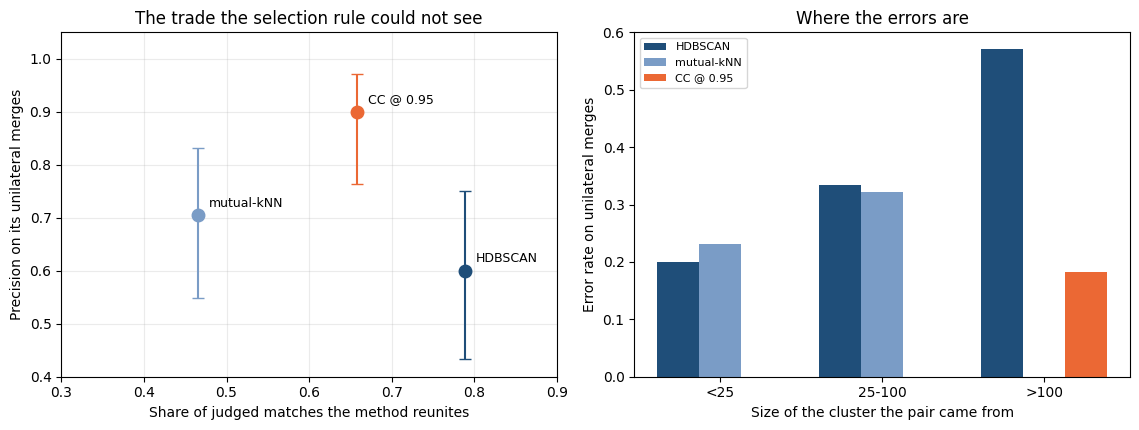

In [8]:
figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))
order = list(fragmentation.method)
colours = ['#1f4e79', '#7a9cc6', '#eb6834']

precision = [1 - unilateral.set_index('method').loc[m, 'error_rate'] for m in order]
lower = [1 - unilateral.set_index('method').loc[m, 'ci95_upper'] for m in order]
upper = [1 - unilateral.set_index('method').loc[m, 'ci95_lower'] for m in order]
recovered = list(fragmentation.true_pairs_recovered)

for position, (name, colour) in enumerate(zip(order, colours)):
    axes[0].errorbar(recovered[position], precision[position],
                     yerr=[[precision[position] - lower[position]],
                           [upper[position] - precision[position]]],
                     fmt='o', color=colour, markersize=9, capsize=4)
    axes[0].annotate(name, (recovered[position], precision[position]),
                     textcoords='offset points', xytext=(8, 6), fontsize=9)
axes[0].set(xlabel='Share of judged matches the method reunites',
            ylabel='Precision on its unilateral merges',
            title='The trade the selection rule could not see',
            xlim=(0.3, 0.9), ylim=(0.4, 1.05))
axes[0].grid(alpha=0.25)

bands = ['<25', '25-100', '>100']
width = 0.26
for offset, (name, colour) in enumerate(zip(order, colours)):
    part = by_size[by_size.method == name].set_index('cluster_size').reindex(bands)
    axes[1].bar(np.arange(len(bands)) + (offset - 1) * width, part.error_rate.fillna(0),
                width=width, color=colour, label=name)
axes[1].set(xticks=np.arange(len(bands)), xticklabels=bands,
            xlabel='Size of the cluster the pair came from',
            ylabel='Error rate on unilateral merges',
            title='Where the errors are')
axes[1].legend(fontsize=8)
figure.tight_layout()
figure.savefig(FIGURES_DIR / 'precision_reach_tradeoff.png', dpi=180, bbox_inches='tight')
plt.show()

**Takeaway.** Weighted back to the composition of the disagreement region, HDBSCAN reunites **79%**
of the pairs judged to show the same design, connected components 66%, mutual-kNN 47%. Precision
and recovery do not order the three methods the same way, which is the trade the selection rule was
unable to see.

The structural columns show what connected components buys its precision with. It produces **1,141
clusters of median size two**, and **60% of them never leave a single work**, a median of one work
per cluster. HDBSCAN produces 140 clusters of median size 22, 86% of which span two or more works,
a median of four. Mutual-kNN is close to HDBSCAN on reach, 85% spanning two or more works, but
recovers the fewest judged matches of the three.

One thing the table shows is *not* a difference between the methods: each concentrates most of its
merged pairs in its largest cluster, 61% for HDBSCAN and 71% for connected components. At 0.95 the
chaining of Section 2 is reduced rather than removed, and the same is true of the selected method.
What separates them is the rest of the clustering. Beyond that one component, connected components
is a list of crop pairs confined to single books, which cannot support a catalogue of recurrent
ornaments whatever its pair precision.

This is the substantive finding of the notebook. The encoded rule scores identity pairs and
weights precision four times over recall, and on adequate evidence that rule points at the method
that merges least. **The criterion, not merely the evidence behind it, was inadequate for the
task**, because nothing in it penalises fragmentation.

## 7. Conclusion

**The chaining assumption was right, and the exclusion it justified was not.** Connected components
collapses 83% of the corpus into one component at the identity threshold, exactly as the protocol
predicted, and is rejected there by the largest-cluster constraint. At 0.95 it does not collapse, it
is eligible, and under the encoded rule it outscores the selected method. Notebook 3's grid
was incomplete.

**On evidence that can discriminate, the selected method is the least precise of the three.** Forty
per cent of the pairs HDBSCAN merges unilaterally are wrong, against ten per cent for connected
components, and the difference is significant by two independent tests. That result survives a
60-of-60 blind re-review and a change of weighting.

**And it reunites the most.** 79% of judged matches against 66% and 47%, with 140 clusters of median
size 22 against 1,141 of median size 2, and 86% of clusters spanning two or more works against 40%.
Sixty per cent of the connected-components clusters never leave a single work, against 14% for
HDBSCAN.

**So the frozen choice stands, on a stated ground rather than on a score.** HDBSCAN is retained
because it is the only candidate that produces groups large and connected enough to be worth
reviewing, and the price of that reach is now measured rather than assumed. The encoded rule
is reported as inadequate for the task, since it rewards fragmentation without limit, and this is
recorded as a finding rather than repaired after the fact.

**What this notebook does not establish.** Every rate here is conditioned on the region where the
methods disagree, which is the hardest material in the corpus by construction. It is not the error
rate of the clustering as a whole, and still less of the reviewed catalogue. That quantity, the
share of what the selected method actually merged that is wrong, is the subject of
`6_WithinClusterAudit`, which samples from the selected clustering's own output rather than from
the disagreement between methods.